In [2]:
from pathlib import Path
import sys

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [3]:
sys.path.append("..")

from src.data import get_dataloaders

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [5]:
dataset_path = Path(
    "/Users/amirhossein/.cache/kagglehub/datasets/"
    "unclesamulus/blood-cells-image-dataset/"
    "versions/2/bloodcells_dataset"
)

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    dataset_path=dataset_path,
    image_size=224,
    batch_size=16
)

In [6]:
#Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/amirhossein/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:05<00:00, 18.6MB/s]


In [7]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [8]:
num_classes = len(class_names)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

model.fc

Linear(in_features=2048, out_features=8, bias=True)

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(), # only training final layer
    lr=0.001
)

In [10]:
num_epochs = 3

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    model.train()

    running_train_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx % 100 == 0:
            print(
                f"Epoch {epoch+1} - "
                f"Batch {batch_idx}/{len(train_loader)}"
            )


        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    train_losses.append(train_loss)

    # Validation
    model.eval()

    running_val_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)

    val_accuracy = correct / total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1 - Batch 0/748
Epoch 1 - Batch 100/748
Epoch 1 - Batch 200/748
Epoch 1 - Batch 300/748
Epoch 1 - Batch 400/748
Epoch 1 - Batch 500/748
Epoch 1 - Batch 600/748
Epoch 1 - Batch 700/748
Epoch [1/3] Train Loss: 0.9267 Val Loss: 0.6457 Val Accuracy: 0.8093
Epoch 2 - Batch 0/748
Epoch 2 - Batch 100/748
Epoch 2 - Batch 200/748
Epoch 2 - Batch 300/748
Epoch 2 - Batch 400/748
Epoch 2 - Batch 500/748
Epoch 2 - Batch 600/748
Epoch 2 - Batch 700/748
Epoch [2/3] Train Loss: 0.5044 Val Loss: 0.4515 Val Accuracy: 0.8787
Epoch 3 - Batch 0/748
Epoch 3 - Batch 100/748
Epoch 3 - Batch 200/748
Epoch 3 - Batch 300/748
Epoch 3 - Batch 400/748
Epoch 3 - Batch 500/748
Epoch 3 - Batch 600/748
Epoch 3 - Batch 700/748
Epoch [3/3] Train Loss: 0.4127 Val Loss: 0.4273 Val Accuracy: 0.8865


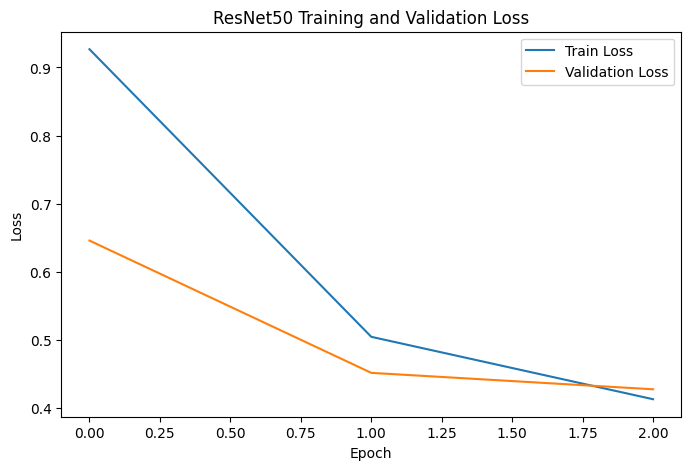

In [11]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()

plt.savefig("../figures/resnet50_loss_curve.png", bbox_inches="tight", dpi=300)

plt.show()

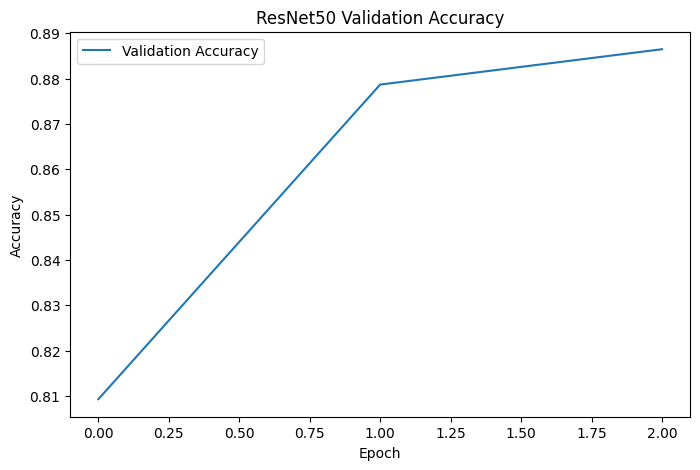

In [12]:
plt.figure(figsize=(8,5))

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Validation Accuracy")
plt.legend()

plt.savefig("../figures/resnet50_validation_accuracy.png", bbox_inches="tight", dpi=300)

plt.show()

In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [14]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    basophil       0.86      0.80      0.83       183
  eosinophil       0.98      0.90      0.94       467
erythroblast       0.86      0.93      0.89       233
          ig       0.79      0.86      0.83       434
  lymphocyte       0.92      0.86      0.89       182
    monocyte       0.85      0.76      0.80       213
  neutrophil       0.87      0.94      0.90       500
    platelet       0.99      0.95      0.97       352

    accuracy                           0.89      2564
   macro avg       0.89      0.87      0.88      2564
weighted avg       0.89      0.89      0.89      2564



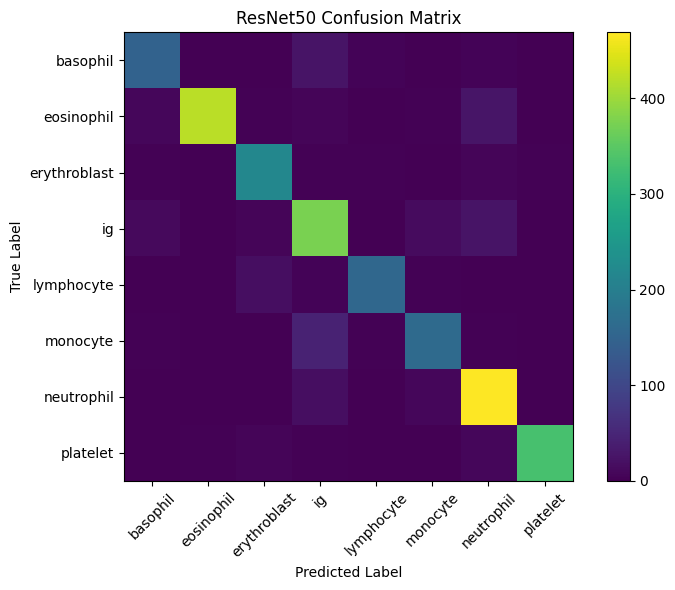

In [15]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.colorbar()
plt.tight_layout()

plt.savefig("../figures/resnet50_confusion_matrix.png", bbox_inches="tight", dpi=300)

plt.show()

## ResNet50 Frozen-Backbone Analysis

### Training Performance

A pretrained ResNet50 model was used with transfer learning. All pretrained layers were frozen and only the final classification layer was trained.

Training loss decreased consistently:

| Epoch | Train Loss |
|---------|---------|
| 1 | 0.927 |
| 2 | 0.504 |
| 3 | 0.413 |

Validation accuracy improved throughout training:

| Epoch | Validation Accuracy |
|---------|---------|
| 1 | 80.93% |
| 2 | 87.87% |
| 3 | 88.65% |

Unlike the CNN baseline, validation accuracy continued improving through the final epoch.

### Test Set Performance

The frozen ResNet50 achieved:

- Test Accuracy: 0.89
- Macro F1-score: 0.88
- Weighted F1-score: 0.89

### Per-Class Performance

Strong performance was observed for:

- eosinophil (F1 = 0.94)
- platelet (F1 = 0.97)
- neutrophil (F1 = 0.90)

More challenging classes included:

- basophil (F1 = 0.83)
- immature granulocyte (F1 = 0.83)
- monocyte (F1 = 0.80)

### Confusion Matrix Analysis

Most predictions lie on the diagonal, indicating good classification performance. However, substantial confusion remains among morphologically similar white blood cell categories, particularly immature granulocytes, monocytes, and neutrophils.

### Comparison with CNN Baseline

| Metric | CNN | Frozen ResNet50 |
|---------|---------|---------|
| Test Accuracy | 0.91 | 0.89 |
| Macro F1 | 0.90 | 0.88 |
| Weighted F1 | 0.91 | 0.89 |

The CNN baseline outperformed the frozen ResNet50 model. This suggests that ImageNet features alone are insufficient for optimal blood cell classification.

### Conclusions

Although transfer learning provided strong performance, freezing the entire pretrained backbone limited the model's ability to adapt to microscopy imagery.

The next experiment will fine-tune selected ResNet50 layers to allow the network to learn blood-cell-specific visual features and potentially surpass the CNN baseline.